# Lab | Hypothesis Testing

## Objetivo

En este lab aplicamos **tests de hipótesis** para tomar decisiones estadísticas a partir de datos.

Trabajaremos con dos datasets:

1. **Pokémon dataset**
2. **California Housing dataset**

La estructura usada será:

1. Definir hipótesis nula y alternativa.
2. Elegir el test adecuado.
3. Fijar el nivel de significancia.
4. Ejecutar el test.
5. Interpretar el p-value.
6. Extraer una conclusión orientada a negocio/datos.

Nivel de significancia usado en todo el notebook:

\[
\alpha = 0.05
\]

# 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

alpha = 0.05

# Challenge 1 — Pokémon Dataset

En este primer bloque trabajamos con datos de Pokémon.

Dataset:

`https://raw.githubusercontent.com/data-bootcamp-v4/data/main/pokemon.csv`

## 1.1 Cargar datos

In [2]:
pokemon_url = "https://raw.githubusercontent.com/data-bootcamp-v4/data/main/pokemon.csv"

df_pokemon = pd.read_csv(pokemon_url)

df_pokemon.head()

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [3]:
df_pokemon.shape

(800, 11)

In [4]:
df_pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        799 non-null    object
 1   Type 1      800 non-null    object
 2   Type 2      414 non-null    object
 3   HP          800 non-null    int64 
 4   Attack      800 non-null    int64 
 5   Defense     800 non-null    int64 
 6   Sp. Atk     800 non-null    int64 
 7   Sp. Def     800 non-null    int64 
 8   Speed       800 non-null    int64 
 9   Generation  800 non-null    int64 
 10  Legendary   800 non-null    bool  
dtypes: bool(1), int64(7), object(3)
memory usage: 63.4+ KB


In [5]:
df_pokemon.describe().T

,count,mean,std,min,25%,50%,75%,max
HP,800.0,69.25875,25.534669,1.0,50.00,65.0,80.0,255.0
Attack,800.0,79.00125,32.457366,5.0,55.00,75.0,100.0,190.0
Defense,800.0,73.84250,31.183501,5.0,50.00,70.0,90.0,230.0
Sp. Atk,800.0,72.82000,32.722294,10.0,49.75,65.0,95.0,194.0
Sp. Def,800.0,71.90250,27.828916,20.0,50.00,70.0,90.0,230.0
Speed,800.0,68.27750,29.060474,5.0,45.00,65.0,90.0,180.0
Generation,800.0,3.32375,1.661290,1.0,2.00,3.0,5.0,6.0


## 1.2 Exploración rápida de columnas relevantes

Antes de hacer los tests, revisamos las columnas que vamos a usar:

- `Type 1`
- `Type 2`
- `HP`
- `Attack`
- `Defense`
- `Sp. Atk`
- `Sp. Def`
- `Speed`
- `Legendary`

In [6]:
df_pokemon.columns

Index(['Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk',
       'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

In [7]:
df_pokemon["Legendary"].value_counts()

Legendary
False    735
True      65
Name: count, dtype: int64

In [8]:
df_pokemon[["Type 1", "Type 2"]].head()

,Type 1,Type 2
0,Grass,Poison
1,Grass,Poison
2,Grass,Poison
3,Grass,Poison
4,Fire,NaN


# Challenge 1.1 — ¿Los Pokémon de tipo Dragon tienen más HP que los de tipo Grass?

## Enunciado

> We posit that Pokemons of type Dragon have, on average, more HP stats than Grass. Choose the proper test and, with 5% significance, comment your findings.

## Tipo de problema

Queremos comparar la media de HP entre dos grupos independientes:

- Pokémon tipo **Dragon**
- Pokémon tipo **Grass**

Como son dos grupos independientes y comparamos una variable numérica (`HP`), usamos un:

## Two Sample T-Test independiente

Usaremos la versión de Welch (`equal_var=False`) porque no asumimos que ambos grupos tengan la misma varianza.

## Hipótesis

\[
H_0: \mu_{Dragon} \leq \mu_{Grass}
\]

\[
H_1: \mu_{Dragon} > \mu_{Grass}
\]

Es un test de una cola porque la hipótesis alternativa plantea que Dragon tiene **más** HP que Grass.

In [9]:
# Seleccionamos Pokémon cuyo Type 1 sea Dragon o Grass
dragon_hp = df_pokemon.loc[
    df_pokemon["Type 1"] == "Dragon",
    "HP"
]

grass_hp = df_pokemon.loc[
    df_pokemon["Type 1"] == "Grass",
    "HP"
]

print("Dragon HP count:", dragon_hp.shape[0])
print("Grass HP count:", grass_hp.shape[0])
print("Dragon HP mean:", dragon_hp.mean())
print("Grass HP mean:", grass_hp.mean())

Dragon HP count: 32
Grass HP count: 70
Dragon HP mean: 83.3125
Grass HP mean: 67.27142857142857


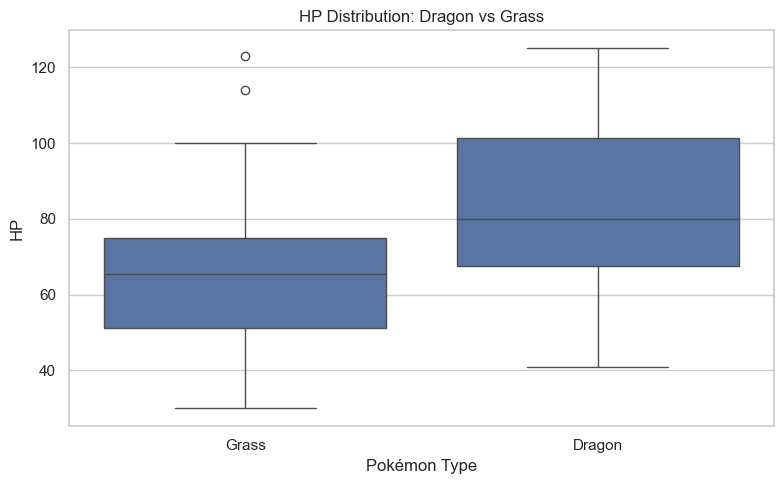

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_pokemon[df_pokemon["Type 1"].isin(["Dragon", "Grass"])],
    x="Type 1",
    y="HP"
)

plt.title("HP Distribution: Dragon vs Grass")
plt.xlabel("Pokémon Type")
plt.ylabel("HP")
plt.tight_layout()
plt.show()

In [11]:
# Welch independent two-sample t-test, one-sided
t_stat, p_value = st.ttest_ind(
    dragon_hp,
    grass_hp,
    equal_var=False,
    alternative="greater"
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Reject H0: Dragon Pokémon have significantly higher HP than Grass Pokémon.")
else:
    print("Fail to reject H0: There is not enough evidence to conclude Dragon Pokémon have higher HP.")

T-statistic: 3.3349632905124063
P-value: 0.0007993609745420597
Reject H0: Dragon Pokémon have significantly higher HP than Grass Pokémon.


## Interpretación

Si el `p-value` es menor que 0.05, rechazamos la hipótesis nula y concluimos que los Pokémon de tipo Dragon tienen, de media, un HP significativamente mayor que los de tipo Grass.

Si el `p-value` es mayor o igual a 0.05, no tenemos evidencia estadística suficiente para afirmar que Dragon tenga más HP que Grass.

# Challenge 1.2 — ¿Los Pokémon legendarios tienen stats diferentes a los no legendarios?

## Enunciado

> We posit that Legendary Pokemons have different stats (HP, Attack, Defense, Sp.Atk, Sp.Def, Speed) when comparing with Non-Legendary. Choose the proper test and, with 5% significance, comment your findings.

## Tipo de problema

Queremos comparar Pokémon legendarios y no legendarios en varias variables numéricas:

- `HP`
- `Attack`
- `Defense`
- `Sp. Atk`
- `Sp. Def`
- `Speed`

Como comparamos dos grupos independientes, usamos **Two Sample T-Tests independientes** para cada stat.

Usamos:

- `equal_var=False`, test de Welch.
- `alternative="two-sided"`, porque queremos saber si son diferentes, no necesariamente mayores o menores.

## Hipótesis para cada stat

\[
H_0: \mu_{Legendary} = \mu_{NonLegendary}
\]

\[
H_1: \mu_{Legendary} 
eq \mu_{NonLegendary}
\]

In [12]:
stats_columns = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

legendary_df = df_pokemon[df_pokemon["Legendary"] == True]
non_legendary_df = df_pokemon[df_pokemon["Legendary"] == False]

print("Legendary Pokémon:", legendary_df.shape[0])
print("Non-Legendary Pokémon:", non_legendary_df.shape[0])

Legendary Pokémon: 65
Non-Legendary Pokémon: 735


In [13]:
# Medias por grupo
mean_stats_comparison = df_pokemon.groupby("Legendary")[stats_columns].mean().T

mean_stats_comparison

Legendary,False,True
HP,67.182313,92.738462
Attack,75.669388,116.676923
Defense,71.559184,99.661538
Sp. Atk,68.454422,122.184615
Sp. Def,68.892517,105.938462
Speed,65.455782,100.184615


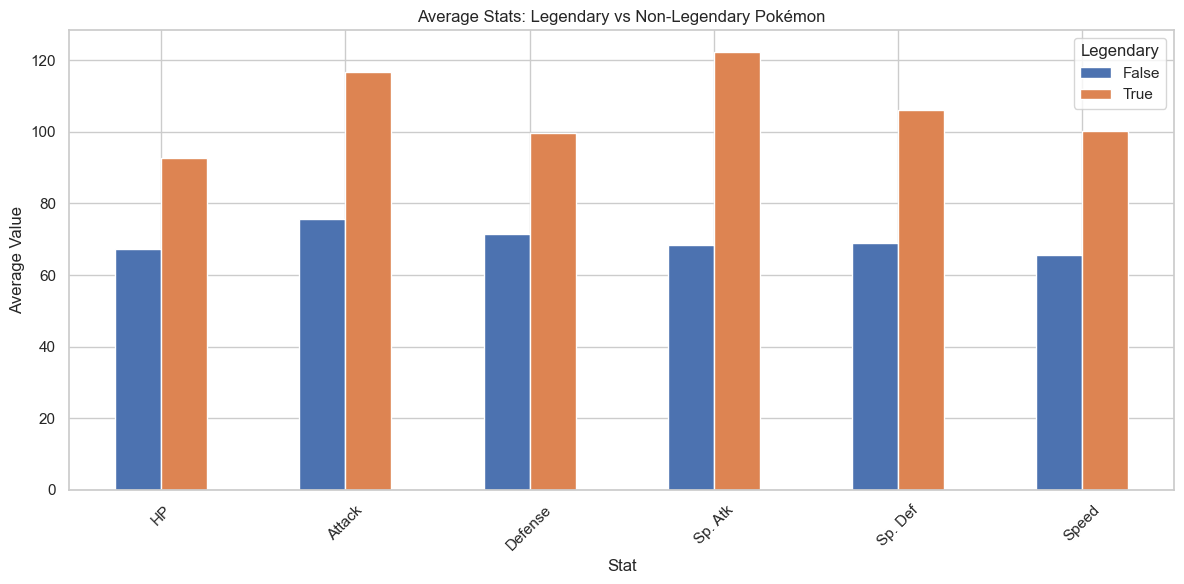

In [14]:
mean_stats_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Stats: Legendary vs Non-Legendary Pokémon")
plt.xlabel("Stat")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Legendary")
plt.tight_layout()
plt.show()

In [15]:
test_results = []

for stat in stats_columns:
    legendary_values = legendary_df[stat]
    non_legendary_values = non_legendary_df[stat]

    t_stat, p_value = st.ttest_ind(
        legendary_values,
        non_legendary_values,
        equal_var=False,
        alternative="two-sided"
    )

    test_results.append({
        "stat": stat,
        "legendary_mean": legendary_values.mean(),
        "non_legendary_mean": non_legendary_values.mean(),
        "t_statistic": t_stat,
        "p_value": p_value,
        "significant_0.05": p_value < alpha
    })

results_df = pd.DataFrame(test_results)

results_df

,stat,legendary_mean,non_legendary_mean,t_statistic,p_value,significant_0.05
0,HP,92.738462,67.182313,8.981370,1.002691e-13,True
1,Attack,116.676923,75.669388,10.438134,2.520372e-16,True
2,Defense,99.661538,71.559184,7.637078,4.826998e-11,True
3,Sp. Atk,122.184615,68.454422,13.417450,1.551461e-21,True
4,Sp. Def,105.938462,68.892517,10.015697,2.294933e-15,True
5,Speed,100.184615,65.455782,11.475044,1.049016e-18,True


## Nota sobre múltiples tests

Estamos realizando 6 tests distintos, uno por cada stat.

En este lab interpretamos cada test con un nivel de significancia del 5%, tal y como pide el enunciado.  
Aun así, en un análisis más estricto se podría aplicar una corrección por múltiples comparaciones, como Bonferroni.

In [16]:
# Corrección opcional de Bonferroni
bonferroni_alpha = alpha / len(stats_columns)

results_df["significant_bonferroni"] = results_df["p_value"] < bonferroni_alpha

print("Alpha original:", alpha)
print("Alpha Bonferroni:", bonferroni_alpha)

results_df

Alpha original: 0.05
Alpha Bonferroni: 0.008333333333333333


,stat,legendary_mean,non_legendary_mean,t_statistic,p_value,significant_0.05,significant_bonferroni
0,HP,92.738462,67.182313,8.981370,1.002691e-13,True,True
1,Attack,116.676923,75.669388,10.438134,2.520372e-16,True,True
2,Defense,99.661538,71.559184,7.637078,4.826998e-11,True,True
3,Sp. Atk,122.184615,68.454422,13.417450,1.551461e-21,True,True
4,Sp. Def,105.938462,68.892517,10.015697,2.294933e-15,True,True
5,Speed,100.184615,65.455782,11.475044,1.049016e-18,True,True


## Interpretación

Para cada stat:

- Si `p_value < 0.05`, rechazamos H0 y concluimos que existen diferencias significativas entre legendarios y no legendarios.
- Si `p_value >= 0.05`, no tenemos evidencia suficiente para afirmar que haya diferencias.

La tabla permite ver qué atributos presentan diferencias estadísticamente significativas.

# Challenge 2 — California Housing Dataset

En este segundo bloque trabajamos con el dataset de California Housing.

Dataset:

`https://raw.githubusercontent.com/data-bootcamp-v4/data/main/california_housing.csv`

## 2.1 Cargar datos

In [17]:
housing_url = "https://raw.githubusercontent.com/data-bootcamp-v4/data/main/california_housing.csv"

df_housing = pd.read_csv(housing_url)

df_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [18]:
df_housing.shape

(17000, 9)

In [19]:
df_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [20]:
df_housing.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,17000.0,-119.562108,2.005166,-124.3500,-121.790000,-118.4900,-118.000,-114.3100
latitude,17000.0,35.625225,2.137340,32.5400,33.930000,34.2500,37.720,41.9500
housing_median_age,17000.0,28.589353,12.586937,1.0000,18.000000,29.0000,37.000,52.0000
total_rooms,17000.0,2643.664412,2179.947071,2.0000,1462.000000,2127.0000,3151.250,37937.0000
total_bedrooms,17000.0,539.410824,421.499452,1.0000,297.000000,434.0000,648.250,6445.0000
population,17000.0,1429.573941,1147.852959,3.0000,790.000000,1167.0000,1721.000,35682.0000
households,17000.0,501.221941,384.520841,1.0000,282.000000,409.0000,605.250,6082.0000
median_income,17000.0,3.883578,1.908157,0.4999,2.566375,3.5446,4.767,15.0001
median_house_value,17000.0,207300.912353,115983.764387,14999.0000,119400.000000,180400.0000,265000.000,500001.0000


# Challenge 2 — ¿Las casas cercanas a una escuela u hospital son más caras?

## Enunciado

> We posit that houses close to either a school or a hospital are more expensive.

Coordenadas:

- School: `(-118, 34)`
- Hospital: `(-122, 37)`

Consideramos que una casa está cerca de una escuela u hospital si la distancia es menor que `0.50`.

## Tipo de problema

Queremos comparar el precio medio de dos grupos independientes:

- Casas cercanas a escuela u hospital.
- Casas lejanas de ambos.

Como comparamos la media de una variable numérica entre dos grupos independientes, usamos:

## Two Sample T-Test independiente

Usaremos Welch (`equal_var=False`) porque no asumimos igualdad de varianzas.

## Hipótesis

\[
H_0: \mu_{close} \leq \mu_{far}
\]

\[
H_1: \mu_{close} > \mu_{far}
\]

Es un test de una cola porque la hipótesis plantea que las casas cercanas son **más caras**.

## 2.2 Crear función de distancia euclídea

In [21]:
def euclidean_distance(longitude, latitude, reference_longitude, reference_latitude):
    distance = np.sqrt(
        (longitude - reference_longitude) ** 2 +
        (latitude - reference_latitude) ** 2
    )

    return distance

## 2.3 Calcular distancia a escuela y hospital

In [22]:
school_coordinates = (-118, 34)
hospital_coordinates = (-122, 37)

df_housing["distance_to_school"] = euclidean_distance(
    df_housing["longitude"],
    df_housing["latitude"],
    school_coordinates[0],
    school_coordinates[1]
)

df_housing["distance_to_hospital"] = euclidean_distance(
    df_housing["longitude"],
    df_housing["latitude"],
    hospital_coordinates[0],
    hospital_coordinates[1]
)

df_housing[[
    "longitude",
    "latitude",
    "distance_to_school",
    "distance_to_hospital"
]].head()

,longitude,latitude,distance_to_school,distance_to_hospital
0,-114.31,34.19,3.694888,8.187319
1,-114.47,34.40,3.552591,7.966235
2,-114.56,33.69,3.453940,8.143077
3,-114.57,33.64,3.448840,8.154416
4,-114.57,33.57,3.456848,8.183508


## 2.4 Crear variable close_to_school_or_hospital

In [23]:
distance_threshold = 0.50

df_housing["close_to_school_or_hospital"] = (
    (df_housing["distance_to_school"] < distance_threshold) |
    (df_housing["distance_to_hospital"] < distance_threshold)
)

df_housing["close_to_school_or_hospital"].value_counts()

close_to_school_or_hospital
False    10171
True      6829
Name: count, dtype: int64

## 2.5 Comparar precios entre casas cercanas y lejanas

In [24]:
# Detectar automáticamente la columna de precio
df_housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'distance_to_school', 'distance_to_hospital',
       'close_to_school_or_hospital'],
      dtype='object')

In [25]:
# En este dataset la variable de precio suele ser median_house_value
price_column = "median_house_value"

close_prices = df_housing.loc[
    df_housing["close_to_school_or_hospital"] == True,
    price_column
]

far_prices = df_housing.loc[
    df_housing["close_to_school_or_hospital"] == False,
    price_column
]

print("Close houses count:", close_prices.shape[0])
print("Far houses count:", far_prices.shape[0])
print("Close houses mean price:", close_prices.mean())
print("Far houses mean price:", far_prices.mean())

Close houses count: 6829
Far houses count: 10171
Close houses mean price: 246951.98213501245
Far houses mean price: 180678.44105790975


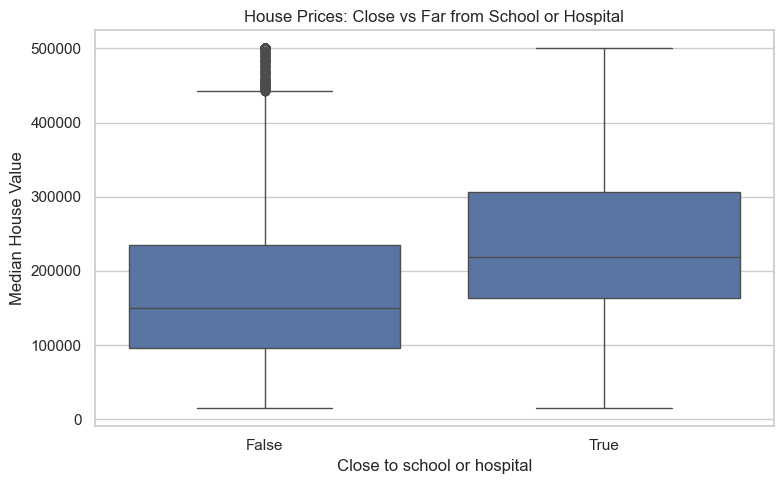

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_housing,
    x="close_to_school_or_hospital",
    y=price_column
)

plt.title("House Prices: Close vs Far from School or Hospital")
plt.xlabel("Close to school or hospital")
plt.ylabel("Median House Value")
plt.tight_layout()
plt.show()

## 2.6 Test de hipótesis

In [27]:
t_stat, p_value = st.ttest_ind(
    close_prices,
    far_prices,
    equal_var=False,
    alternative="greater"
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Reject H0: houses close to a school or hospital are significantly more expensive.")
else:
    print("Fail to reject H0: there is not enough evidence to conclude close houses are more expensive.")

T-statistic: 37.992330214201516
P-value: 1.5032478884296307e-301
Reject H0: houses close to a school or hospital are significantly more expensive.


## Interpretación

Si el `p-value` es menor que 0.05, rechazamos H0 y concluimos que las casas cercanas a una escuela u hospital son significativamente más caras.

Si el `p-value` es mayor o igual que 0.05, no hay evidencia suficiente para afirmar que las casas cercanas sean más caras.

# Conclusiones finales

## Challenge 1.1

Se comparó el HP medio de Pokémon Dragon y Grass usando un **Two Sample T-Test independiente de Welch** con hipótesis alternativa unilateral.

## Challenge 1.2

Se compararon varios stats entre Pokémon legendarios y no legendarios usando **Two Sample T-Tests independientes de Welch** para cada variable.

## Challenge 2

Se calculó la distancia euclídea de cada vivienda a una escuela y a un hospital. Después se dividió el dataset en viviendas cercanas y lejanas, y se aplicó un **Two Sample T-Test independiente de Welch** para comprobar si las viviendas cercanas son más caras.

## Recomendación metodológica

En todos los casos se ha seguido el flujo:

1. Plantear H0 y H1.
2. Elegir test según tipo de variables y grupos.
3. Aplicar nivel de significancia de 0.05.
4. Interpretar p-value.
5. Extraer conclusión.